# Data Processing (70%)

Using standard python (No pandas / seaborn) with default libraries (os, sys, time, json, csv, …) 

7 tasks

In [1]:
import csv
import json
import pandas as pd
import seaborn as sns

# Task 1 - Read in the provided ACW Data using the CSV library.

In [2]:
#FINAL ANSWER
with open("acw_user_data.csv" , mode = "r" ) as csvFile : #file has been read
    print(csvFile)
    print(type(csvFile))

<_io.TextIOWrapper name='acw_user_data.csv' mode='r' encoding='cp1252'>
<class '_io.TextIOWrapper'>


0 ['Address Street', 'Address City', 'Address Postcode', 'Age (in Years)', 'Distance Commuted to Work (in Km)', 'Employer Company', 'Credit Card Start Date', 'Credit Card Expiry Date', 'Credit Card Number', 'Credit Card CVV', 'Dependants', 'First Name', 'Bank IBAN Number', 'Last Name', 'Marital Status', 'Yearly Pension (in Dollars)', 'Retired', 'Yearly Salary (in Dollars)', 'Sex', 'Vehicle Make', 'Vehicle Model', 'Vehicle Year', 'Vehicle Type']

# Task 2

In [3]:
#FINAL ANSWER


#    Searches thru CSV file and categorizes information into lists of dictionaries.
    
#    Arg:
#        CSVArgument,, The file path to the CSV data.
        
#    Returns:
#        Three lists containing dictionaries for Vehicle, Bank, and Address details.
    

#input CSV as CSVArgument
def ExtractDataFunc( CSVArgument ) :
    VehicleDetailsList = []
    BankDetailsList = []
    AddressDetailsList = []

    #read CSV
    with open( CSVArgument , mode = "r" ) as CSVArgument_UserData :
        UserData_reader = csv.reader( CSVArgument_UserData )
        for row_number, row_item in enumerate(UserData_reader) :
            # Skip header row,,
            if row_number == 0 :
                continue
            else :
                # A - Vehicle Details,, cast int if necessary
                VehicleDetailsList.append({
                "Make" : row_item[19],
                "Model"  : row_item[20],
                "Year" : int(row_item[21]),
                "Type" : row_item[22],
                })

                # B - Bank Details,, cast int if necessary
                BankDetailsList.append({
                "Start Date" : row_item[6],                        #1
                "Expiry Date"  : row_item[7],                      #2
                "Credit Card Number" : int(row_item[8]),           #3
                "CVV" : int(row_item[9]),                               #4
                "IBAN Number" : row_item[12]                        #5
                })

                # C - Address Details
                AddressDetailsList.append({
                "Street": row_item[0] ,
                "City": row_item[1] ,
                "Postcode":  row_item[2] ,                
                })

    return VehicleDetailsList , BankDetailsList , AddressDetailsList

VehicleDict , BankDict, AddressDict = ExtractDataFunc("acw_user_data.csv")

# Task 3


The client informs you that they have had difficulty with errors in the dependants column. Some entries are empty (i.e. “ “ or “”), which may hinder your conversion from Task 2. These should be changed into something meaningful when encountered.

In [4]:
#FINAL ANSWER pt.1

# Search CSV to find rows with missing 'Dependants' data
# verify the scale of the data quality issue before fix

# no none types so i can assume that “ “ or “” are my only issues

with open("acw_user_data.csv" , mode = "r" ) as UserData :
    UserData_reader = csv.reader( UserData, delimiter=',' )
    problematicRows = []
    for row_number, row_item in enumerate(UserData_reader) :
        if row_number == 0 :
            continue
        elif row_item[10] == "" or row_item[10] == " " :
            problematicRows.append(row_number)
print(f"Problematic entries found at: {problematicRows}")

Problematic entries found at: [22, 110, 180, 206, 271, 273, 275, 359, 461, 469, 580, 637, 680, 726, 823, 866, 918, 932, 984]


In [5]:
# FINAL ANSWER pt.2


# Data Clean
# replace empty 'Dependants' entries with "0" 


UserDataFull = []

with open("acw_user_data.csv" , mode = "r", newline='' ) as UserData :
    UserData_reader = csv.reader( UserData, delimiter=',' )
    for row_number, row_item in enumerate(UserData_reader) :
        if row_item[10] == "" or row_item[10] == " " :
            row_item[10] = "0"
            UserDataFull.append(row_item)
        else :
            UserDataFull.append(row_item)
            
# Save the cleaned dataset to a new file ("AA_acw_user_data.csv")
# preserves original data
with open("AA_acw_user_data.csv" , mode = "w" , newline='') as UserDataCopy :
    UserData_writer = csv.writer( UserDataCopy, delimiter=',' )
    UserData_writer.writerows(UserDataFull)

#had to explicitly write " newline = '' " otherwise empty lists would be created inbetween

# Task 4

In [6]:
#FINAL ANSWER

#    Combine user data from CSV with Vehicle/Bank/Address Dict and export to JSON
def startTASK4() :
    GeneralDetailsList = []

    with open( "AA_acw_user_data.csv" , mode = "r" ) as CSVArgument_UserData :
        UserData_reader = csv.reader( CSVArgument_UserData )
        for row_number, row_item in enumerate(UserData_reader) :
            # skip header
            if row_number == 0 :
                continue
            else :
                #convert to int if necessary
                IndividualDict = {
                    "First Name": row_item[11],
                    "Last Name": row_item[13],
                    "Age": int(row_item[3]),
                    "Sex": row_item[18],
                    "Retired": row_item[16],
                    "Marital Status": row_item[14],
                    "Dependants": int(row_item[10]) ,
                    "Yearly Salary": float(row_item[17]),
                    "Yearly Pension": float(row_item[15]),
                    "Employer Company": row_item[5],
                    "Distance Commuted to Work (Km)": float(row_item[4]),
                    "Vehicle Details": VehicleDict[row_number -1],
                    "Bank Details": BankDict[row_number -1],
                    "Address Details": AddressDict[row_number -1]
                }
                GeneralDetailsList.append(IndividualDict)
#used [row_number - 1] to map the CSV row to the 0-indexed 
    
    #export to JSON
    with open( "processed.json" , mode = "w" ) as FullDetailsJSON :
        json.dump(GeneralDetailsList, FullDetailsJSON)
        
startTASK4()

# Task 5

In [7]:
#FINAL ANSWER


#    Reads processed user data and categorizes individuals into separate 
#    dictionaries based on their retirement status.


#11 First Name
#13 Last Name
#16 Retired    expressed as True or False


def EmplotmentStatusFunc() :
    with open("AA_acw_user_data.csv" , mode = "r" ) as UserData :
        UserData_reader = csv.reader( UserData, delimiter=',' )

        RetiredDict = {}
        EmployedDict = {}
        
        for row_number, row_item in enumerate(UserData_reader) :
            #skip header
            if row_number == 0 :
                continue
                
             # check 'Retired' status at index 16
             # if True, add to the retired dictionary; else, add to employed   
            if row_item[16] == "True"  :
                # combine first and last name to create key for dictionaries
                EmployeeName = (row_item[11] + " " + row_item[13])
                RetiredDict[EmployeeName] = "Retired"
            else :
                EmployeeName = (row_item[11] + " " + row_item[13])
                EmployedDict[EmployeeName] = "Employed"
                
        #outputs retired json
        with open("retired.json", mode = "w") as RetiredJSON :
            json.dump(RetiredDict , RetiredJSON)

        #outputs emplyed json
        with open("employed.json", mode = "w") as EmployedJSON :
            json.dump(EmployedDict , EmployedJSON)

            
EmplotmentStatusFunc() 

# Task 6

The client states that there may be some issues with credit card entries. Any customers that have more than 10 years between their start and end date need writing to a separate file, called remove_ccard.json, in the JSON data format. The client will manually deal with these later based on your output. They request that you write a function to help perform this, which accepts a single row from the CSV data, and outputs whether the row should be flagged. This can then be used when determining whether to write the current person to the remove_ccard file. Note the dates are shown in the format used on credit cards which is “MM/YY”.

In [8]:
#FINAL ANSWER pt. 1
# // this outputs flagged cards to JSON

def task6( ) :
    with open("AA_acw_user_data.csv" , mode = "r" ) as UserData :
        UserData_reader = csv.reader( UserData, delimiter=',' )
        problematicCardsDict = {}
        NewProblematicCardRows = []
        for rowNumber, rowItem in enumerate(UserData_reader) :
            #skip header
            if rowNumber == 0 :
                continue
            #call the date func using Start Date (index 6) and Expiry Date (index 7)
            if NewStandardizeDateFunc(rowItem[6], rowItem[7]) == True :
                # if card exceeds the 10-year limit, track row and owner
                NewProblematicCardRows.append(rowNumber)
                EmployeeName = (rowItem[11] + " " + rowItem[13])
                #description of status...
                problematicCardsDict[EmployeeName] = f"card at row {rowNumber} has been flagged"
            else :
                continue
            #output flagged entries to JSON
        with open("remove_ccard.json", mode = "w") as CardJSON :
            json.dump(problematicCardsDict , CardJSON)
            


def NewStandardizeDateFunc(startDate, endDate) :
#    Calculates the duration between two dates in months.
#    Returns True if the duration is over 120 months (10 years).
    
        # split "MM/YY" string into a list [MM, YY],, convert year to months
        startDate = startDate.split("/")
        months = int(startDate[0])
        YearInMonths = (int(startDate[1]) + 2000) * 12
        totalValueinMonthsStart = YearInMonths + months

        endDate = endDate.split("/")
        months = int(endDate[0])
        YearInMonths = (int(endDate[1]) + 2000) * 12
        totalValueinMonthsEnd = YearInMonths + months

        TrueTotalValueinMonths = totalValueinMonthsEnd - totalValueinMonthsStart
    
    # flag cards valid for more than 10 years (120 months)
        if TrueTotalValueinMonths > 120 :
            return True
        
    
task6( )

In [9]:
#FINAL ANSWER pt.2
# // this is the tool to be used by the client


#    Search CSV for specific row index and validates the 
#    credit card dates for that specific entry.

def task6part2( rowNumberArgument ) :
        with open("AA_acw_user_data.csv" , mode = "r" ) as UserData :
            UserData_reader = csv.reader( UserData, delimiter=',' )

            for rowNumber, rowItem in enumerate(UserData_reader) :
                # target only row requested by client
                if rowNumber == rowNumberArgument :
                    startDate = rowItem[6]
                    endDate = rowItem[7]

                    # check if this specific card meets the 10-year condition
                    if NewStandardizeDateFunc(startDate, endDate) == True :
                        print("Entry at row number: ", rowNumber, "should be flagged")
                        return True # stop searching and return result
                    else :
                        print("Entry at row number: ", rowNumber, "should NOT be flagged")
                        return False




#not necessary to add function here,, but did so for clarity's sake
def NewStandardizeDateFunc(startDate, endDate) :
#    Calculates the duration between two dates in months.
#    Returns True if the duration is over 120 months (10 years).
        startDate = startDate.split("/")
        months = int(startDate[0])
        YearInMonths = (int(startDate[1]) + 2000) * 12
        totalValueinMonthsStart = YearInMonths + months

        endDate = endDate.split("/")
        months = int(endDate[0])
        YearInMonths = (int(endDate[1]) + 2000) * 12
        totalValueinMonthsEnd = YearInMonths + months

        TrueTotalValueinMonths = totalValueinMonthsEnd - totalValueinMonthsStart

        if TrueTotalValueinMonths > 120 :
            return True
        


# User Input Loop
# use 'while True' to keep the program running until user provides a valid row number
while True :
    try :
        # request a specific record index from the client
        clientInput = input("Enter row number: ")
        rowNumberArgument = int(clientInput)    # Attempt to convert input to an integer
        if rowNumberArgument < 0:   #Row indices must be positive integers
            print("Row numbers cannot be negative")
            continue
        value = task6part2( rowNumberArgument )
        # if function finishes the file without finding the row, 'value' will be None
        if value == None  :
            print("Row not in file.")
        else:
            break #exit loop if valid input found

    except ValueError:
        print("Invalid input, please input only a number.")    
        # catch error cases where the user types text instead of a number

Enter row number:  9


Entry at row number:  9 should NOT be flagged


In [10]:
#am i expected to use input() to allow the client to input the row number or should i assume he can input it into the function?

# Task 7

You have been tasked with calculating some additional metrics which will be used for ranking customers. You should create a new data attribute for our customers called “Salary-Commute”. Reading in from processed.json:


Add, and calculate appropriately, this new attribute. It should represent the Salary that a customer earns, per Km of their commute.

Note: If a person travels 1 or fewer commute Km, then their salary-commute would be just their salary.

B) Sort these records by that new metric, in ascending order.

C) Store the output file out as a JSON format, for a commute.json file.

In [11]:
#FINAL ANSWER

def KeyFunc(employee):
# helper function used as sorting key
# it tells the sort() method to look specifically at the 'Salary/Commute' value
    return employee["Salary/Commute"]

with open("processed.json" , mode = "r" ) as ProcessedJSON :
    processed = json.load(ProcessedJSON)

    for employee in processed:
        Salary = employee["Yearly Salary"]
        Commute = employee["Distance Commuted to Work (Km)"]
        # if commute is 1km or less, use full salary
        if Commute <= 1:
            SalaryCommute = Salary
            employee["Salary/Commute"] = SalaryCommute
        else:
            # calculate salary earned per kilometer of commute
            SalaryCommute = (Salary/Commute)
            employee["Salary/Commute"] = SalaryCommute
    # sort the list of dictionaries in-place
    processed.sort(key = KeyFunc)

#save the updated and ranked data to JSON 
with open("commute.json" ,  mode = "w" ) as CommuteJSON :
    json.dump(processed, CommuteJSON)

# Data Visualization

Using Pandas and Seaborn
Your client wishes to understand the data they have on their customers a bit more by use of visualisations. With use of Pandas and Seaborn read in the original CSV file provided with the assignment.

4 Tasks

## Task 1

In [12]:
aws_df = pd.read_csv("acw_user_data.csv")

print(aws_df)

                Address Street    Address City Address Postcode  \
0                70 Lydia isle      Lake Conor          S71 7XZ   
1             00 Wheeler wells      Chapmanton           L2 7BT   
2         Studio 33K Joel walk  Randallborough         ME3N 1GH   
3    Studio 46S Bethany lights      East Reece          E10 9RJ   
4       Flat 3 Christine views    Fletcherstad          WS2 9SN   
..                         ...             ...              ...   
995   Studio 6 Heather prairie    North Amelia           E9 0HB   
996          Flat 3 Davies run      Greenshire           E7 4UJ   
997     Flat 7 Barber motorway    Burrowsshire          L62 8TA   
998              00 Tony forks       Abbiebury          NP4 1JL   
999       Flat 9 Mohamed route       West Glen         LL3M 4WS   

     Age (in Years)  Distance Commuted to Work (in Km)  \
0                89                               0.00   
1                46                              13.72   
2                22  

In [13]:
print(type(aws_df))

<class 'pandas.core.frame.DataFrame'>


In [14]:
print(aws_df.columns)

Index(['Address Street', 'Address City', 'Address Postcode', 'Age (in Years)',
       'Distance Commuted to Work (in Km)', 'Employer Company',
       'Credit Card Start Date', 'Credit Card Expiry Date',
       'Credit Card Number', 'Credit Card CVV', 'Dependants', 'First Name',
       'Bank IBAN Number', 'Last Name', 'Marital Status',
       'Yearly Pension (in Dollars)', 'Retired', 'Yearly Salary (in Dollars)',
       'Sex', 'Vehicle Make', 'Vehicle Model', 'Vehicle Year', 'Vehicle Type'],
      dtype='object')


In [15]:
aws_df.describe()

,Age (in Years),Distance Commuted to Work (in Km),Credit Card Number,Credit Card CVV,Dependants,Yearly Pension (in Dollars),Yearly Salary (in Dollars),Vehicle Year
count,1000.000000,1000.000000,1.000000e+03,1000.000000,981.000000,1000.000000,1000.000000,1000.000000
mean,54.302000,10.457770,4.188020e+17,932.482000,2.135576,5875.413000,57814.078000,2006.927000
std,21.319646,6.951997,1.304208e+18,1626.125269,0.977799,10986.507761,23270.417139,8.211035
min,18.000000,0.000000,6.041600e+10,2.000000,1.000000,0.000000,17046.000000,1992.000000
25%,36.000000,5.637500,3.857314e+13,277.000000,1.000000,0.000000,39089.750000,2000.000000
50%,54.000000,12.170000,3.510666e+15,559.500000,2.000000,0.000000,57518.000000,2008.000000
75%,72.000000,16.262500,4.635909e+15,833.250000,3.000000,0.000000,77211.500000,2014.000000
max,91.000000,20.340000,4.967327e+18,9977.000000,5.000000,46117.000000,98915.000000,2020.000000


In [16]:
#FINAL ANSWER

SalaryColumn = aws_df["Yearly Salary (in Dollars)"]
AgeColumn = aws_df["Age (in Years)"]

print(SalaryColumn.mean())
print(AgeColumn.median())

57814.078
54.0


## Task 2

Perform univariate plots of the following data attributes:
- A) Age, calculating how many bins would be required for a bin_width of 5.
- B )Dependents, fixing data errors with seaborn itself.
- C) Age (of default bins), conditioned on Marital Status


### A)

<Axes: xlabel='Age (in Years)', ylabel='Count'>

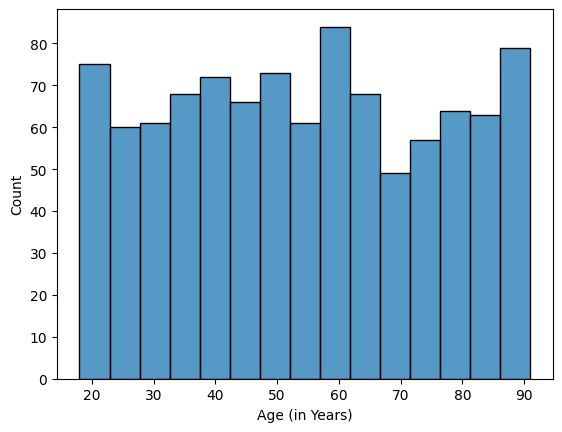

In [17]:
sns.histplot(aws_df, x= "Age (in Years)", binwidth=5)

In [18]:
binNumber = (AgeColumn.max() - AgeColumn.min()) / 5

print(binNumber)
# i guess i round it to 15

binNumber = int(binNumber.round())
print(binNumber)

14.6
15


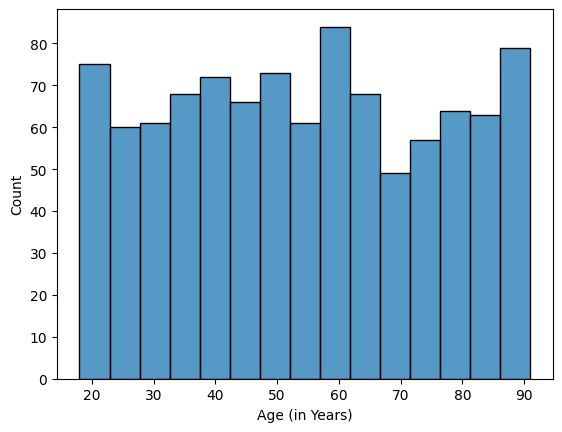

In [19]:
Task2_a = sns.histplot(aws_df, x= "Age (in Years)", bins=binNumber).get_figure()

### B) Dependents, fixing data errors with seaborn itself.

In [20]:
aws_df["Dependants"].unique()

array([ 3.,  1.,  2.,  4., nan,  5.])

In [21]:
aws_df["Dependants"] = aws_df["Dependants"].fillna(0)

In [22]:
aws_df["Dependants"].unique()

array([3., 1., 2., 4., 0., 5.])

In [23]:
aws_df["Dependants"] = aws_df["Dependants"].fillna(0).astype(int)

In [24]:
aws_df["Dependants"].unique()

array([3, 1, 2, 4, 0, 5])

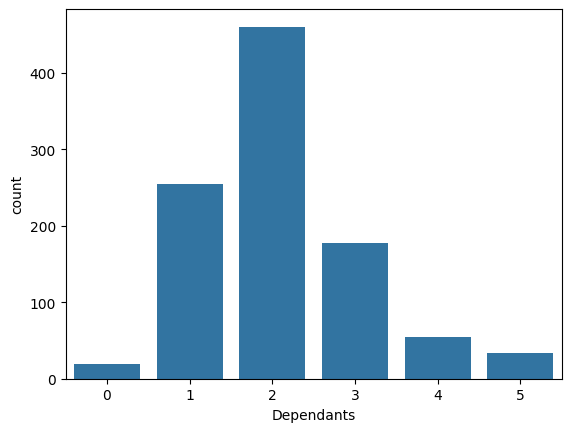

In [25]:
Task2_b = sns.countplot(data=aws_df, x="Dependants").get_figure()

### C) Age (of default bins), conditioned on Marital Status

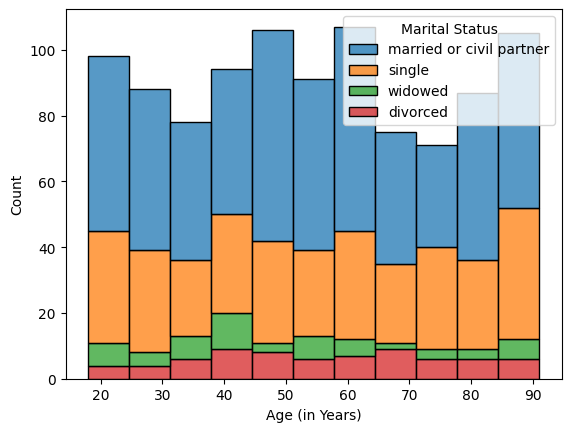

In [26]:
Task2_c = sns.histplot(data = aws_df, x= "Age (in Years)", hue = "Marital Status", multiple="stack").get_figure()

## Task 3

Perform multivariate plots with the following data attributes:
- A) Commuted distance against salary.
- B) Age against Salary
- C) Age against Salary conditioned by Dependants

### A) Commuted distance against salary.

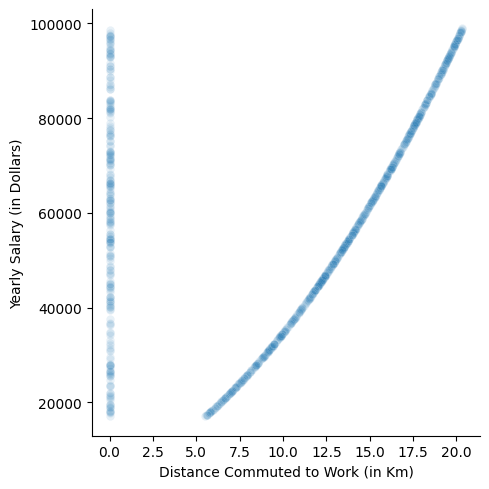

In [27]:
Task3_a = sns.relplot(data=aws_df, x='Distance Commuted to Work (in Km)', y='Yearly Salary (in Dollars)', alpha=0.1)

In [28]:
# opacity jitter edited

### B) Age against Salary

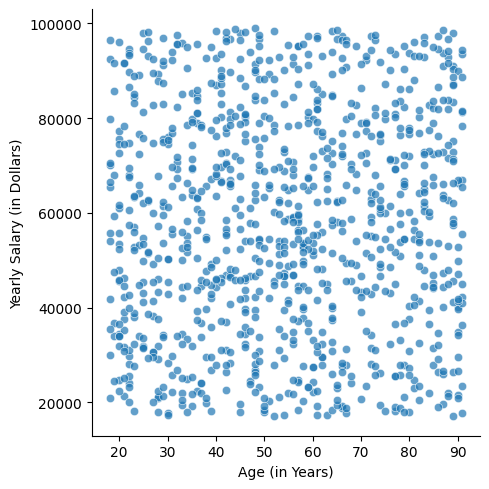

In [29]:
Task3_b = sns.relplot(data=aws_df, x='Age (in Years)', y='Yearly Salary (in Dollars)', alpha=0.7)

In [30]:
# opacity jitter edited

### C) Age against Salary conditioned by Dependants

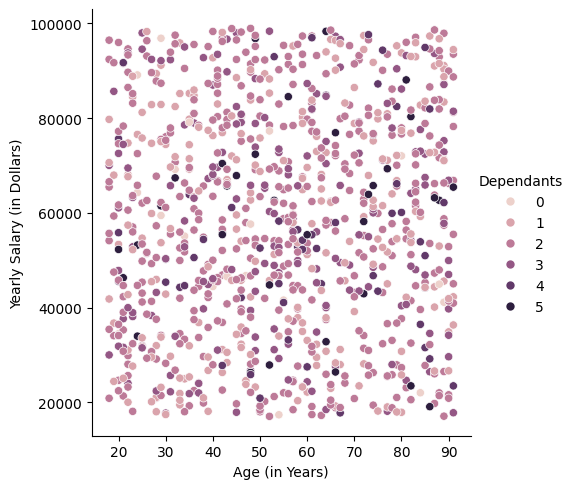

In [31]:
Task3_c = sns.relplot(data=aws_df, x='Age (in Years)', y='Yearly Salary (in Dollars)' ,  hue = "Dependants")

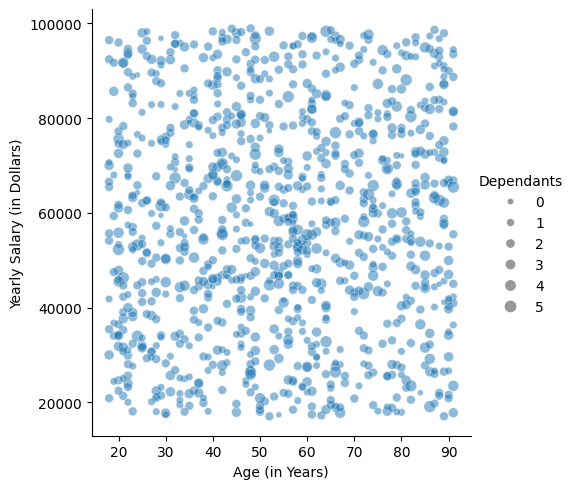

In [32]:
sns.relplot(data=aws_df, x='Age (in Years)', y='Yearly Salary (in Dollars)' ,  size = "Dependants", alpha=0.5)

In [33]:
# opacity jitter edited,, prefer previous tho

## Task 4

In [34]:
figures_to_save ={
    "./Task2_A.png" : Task2_a,
    "./Task2_B.png" : Task2_b,
    "./Task2_C.png" : Task2_c,
    "./Task3_A.png" : Task3_a,
    "./Task3_B.png" : Task3_b,
    "./Task3_c.png" : Task3_c

}

In [35]:
for filename, handle in figures_to_save.items():
    handle.savefig(filename)

#### Other

In [36]:
# Additional parameters may be used to modify the plots to improve readability and information conveyance.